[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Skyline\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Skyline\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Skyline\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


NLTK data downloaded successfully.
Headline Length Statistics:
count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

Top 10 Publishers by Article Count:
publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64

Number of invalid dates: 0

Publication Frequency (Top 10 Dates):
date_only
2009-02-14    1
2009-04-27    2
2009-04-29    1
2009-05-22    1
2009-05-27    6
2009-05-29    2
2009-05-30    3
2009-06-01    5
2009-06-02    2
2009-06-05    6
Name: count, dtype: int64


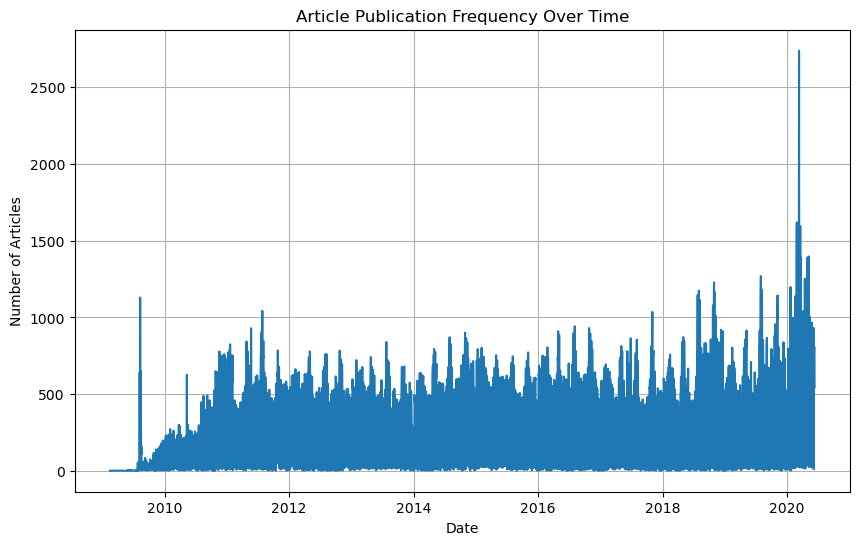


Top 10 Keywords:
[('stocks', 161702), ('vs', 138835), ('eps', 128801), ('est', 122289), ('shares', 114140), ('reports', 108688), ('update', 91645), ('market', 91080), ('earnings', 87183), ('sales', 79528)]

Top 10 Publisher Domains:
publisher_domain
benzinga.com              7937
gmail.com                  139
andyswan.com                 5
investdiva.com               2
tothetick.com                2
eosdetroit.io                1
forextraininggroup.com       1
stockmetrix.net              1
Name: count, dtype: int64


In [59]:

import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from collections import Counter

# Download NLTK data
print("Downloading NLTK data...")
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
print("NLTK data downloaded successfully.")

# Load the dataset
news_df = pd.read_csv('../data/raw_analyst_ratings.csv')

# Descriptive Statistics: Headline length
news_df['headline_length'] = news_df['headline'].apply(len)
print("Headline Length Statistics:")
print(news_df['headline_length'].describe())

# Descriptive Statistics: Articles per publisher
publisher_counts = news_df['publisher'].value_counts()
print("\nTop 10 Publishers by Article Count:")
print(publisher_counts.head(10))

# Date Analysis: Publication date trends
news_df['date'] = pd.to_datetime(news_df['date'], format='mixed', dayfirst=False, errors='coerce', utc=True)
print("\nNumber of invalid dates:", news_df['date'].isna().sum())
news_df['date_only'] = news_df['date'].dt.date
date_counts = news_df['date_only'].value_counts().sort_index()
print("\nPublication Frequency (Top 10 Dates):")
print(date_counts.head(10))

# Visualize publication frequency
date_counts.plot(kind='line', figsize=(10, 6))
plt.title('Article Publication Frequency Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Articles')
plt.grid(True)
plt.savefig('../notebooks/publication_frequency.png')
plt.show()

# Text Analysis: Keyword extraction
stop_words = set(stopwords.words('english'))
def extract_keywords(text):
    # Check if text is a valid string
    if not isinstance(text, str):
        return []
    tokens = word_tokenize(text.lower())
    keywords = [word for word in tokens if word.isalnum() and word not in stop_words]
    return keywords

news_df['keywords'] = news_df['headline'].apply(extract_keywords)
all_keywords = [keyword for keywords in news_df['keywords'] for keyword in keywords]
keyword_freq = Counter(all_keywords)
print("\nTop 10 Keywords:")
print(keyword_freq.most_common(10))

# Publisher Analysis: Extract domains
news_df['publisher_domain'] = news_df['publisher'].str.extract(r'@([\w\.-]+)')
domain_counts = news_df['publisher_domain'].value_counts()
print("\nTop 10 Publisher Domains:")
print(domain_counts.head(10))
